## Парсинг и сборка датасета финансовых компаний с последующим анализом данных и подсчётом статистических метрик.

In [11]:
%%timeit -n 1 -r 1
global get_inn, get_org_id, create_session, extract_financials, build_dataframe, analys_for_growth, build_counts_data, graph_plotting
from parsing import get_inn, get_org_id, create_session, extract_financials, build_dataframe, analys_for_growth, build_counts_data, graph_plotting


44.7 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


### 1) Агрегация данных.

Подготавливаем данные для парсинга. Извлекаем малые и средние предприятия с типом субъекта юридическое лицо, основной вид деятельности начинаается с кода 41.20.

### 2) Парсинг сайта bo.nalog.gov.ru

In [15]:
%%timeit -n 1 -r 1

inn_data = get_inn()
session = create_session()

result = []
total = len(inn_data)
for count, inn in enumerate(inn_data, 1):
    try:
        org_id = get_org_id(session, inn)
        company_fin = extract_financials(session, org_id, inn)
        if company_fin:
            result.append(company_fin)
    except requests.RequestException as e:
        logging.error(f"[{count}/{total}] Сетевая ошибка для ИНН {inn}: {e}")

    except (ValueError, KeyError, TypeError, IndexError) as e:
        logging.warning(f"[{count}/{total}] Ошибка данных для ИНН {inn}: {e}")

    if count % 10 == 0:
        print(f"Обаботано: {count/total}")

if not result:
    logging.critical("Не удалось собрать данные ни по одной компании. Работа прервана.")
    print("Не удалось собрать данные, проверьте .log-файл")
    sys.exit(1)

logging.info(f"Сбор завершён. Успешно получены данные по {len(result)} компаниям.")

Обаботано: 0.01
Обаботано: 0.02
Обаботано: 0.03
Обаботано: 0.04
Обаботано: 0.05
Обаботано: 0.06
Обаботано: 0.07
Обаботано: 0.08
Обаботано: 0.09
Обаботано: 0.1
Обаботано: 0.11
Обаботано: 0.12
Обаботано: 0.13
Обаботано: 0.14
Обаботано: 0.15
Обаботано: 0.16
Обаботано: 0.17
Обаботано: 0.18
Обаботано: 0.19
Обаботано: 0.2
Обаботано: 0.21
Обаботано: 0.22
Обаботано: 0.23
Обаботано: 0.24
Обаботано: 0.25
Обаботано: 0.26
Обаботано: 0.27
Обаботано: 0.28
Обаботано: 0.29


Обаботано: 0.3
Обаботано: 0.31
Обаботано: 0.32
Обаботано: 0.33
Обаботано: 0.34
Обаботано: 0.35
Обаботано: 0.36
Обаботано: 0.37
Обаботано: 0.38
Обаботано: 0.39
Обаботано: 0.4
Обаботано: 0.41
Обаботано: 0.42
Обаботано: 0.43
Обаботано: 0.44
Обаботано: 0.45


Обаботано: 0.46


Обаботано: 0.47
Обаботано: 0.48
Обаботано: 0.49


Обаботано: 0.5
Обаботано: 0.51
Обаботано: 0.52
Обаботано: 0.53
Обаботано: 0.54
Обаботано: 0.55
Обаботано: 0.56
Обаботано: 0.57
Обаботано: 0.58
Обаботано: 0.59
Обаботано: 0.6
Обаботано: 0.61
Обаботано: 0.62
Обаботано: 0.63
Обаботано: 0.64
Обаботано: 0.65
Обаботано: 0.66
Обаботано: 0.67
Обаботано: 0.68


Обаботано: 0.69
Обаботано: 0.7
Обаботано: 0.71
Обаботано: 0.72
Обаботано: 0.73
Обаботано: 0.74
Обаботано: 0.75
Обаботано: 0.76
Обаботано: 0.77
Обаботано: 0.78
Обаботано: 0.79
Обаботано: 0.8
Обаботано: 0.81
Обаботано: 0.82


Обаботано: 0.83
Обаботано: 0.84
Обаботано: 0.85
Обаботано: 0.86
Обаботано: 0.87
Обаботано: 0.88
Обаботано: 0.89
Обаботано: 0.9
Обаботано: 0.91
Обаботано: 0.92
Обаботано: 0.93
Обаботано: 0.94
Обаботано: 0.95


Обаботано: 0.96
Обаботано: 0.97
Обаботано: 0.98


Обаботано: 0.99
Обаботано: 1.0
6min 15s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


### 3) Построение датафрейма и анализ данных.

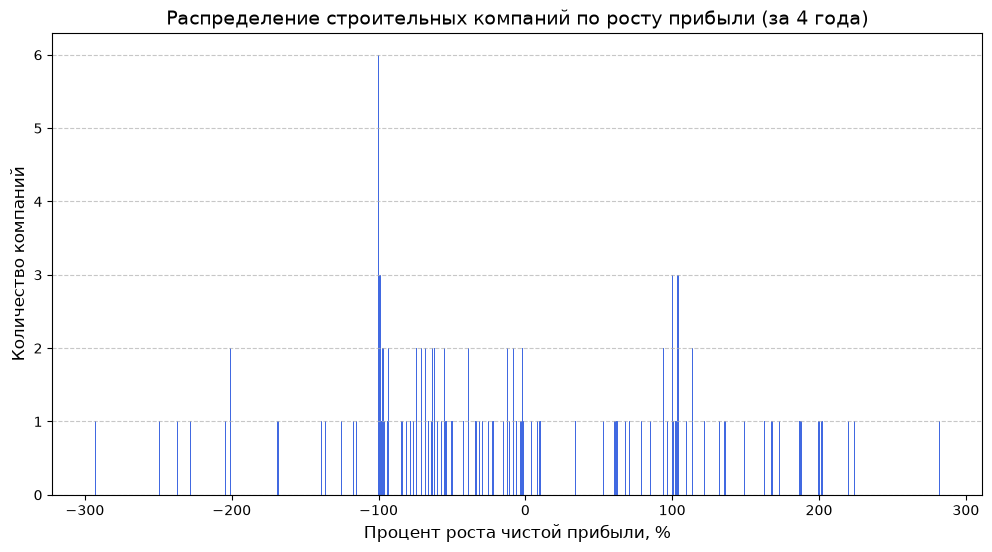

226 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [19]:
%%timeit -n 1 -r 1

N = 4
df_results = build_dataframe(result)
df_results = analys_for_growth(df_results, N)
counts_data = build_counts_data(df_results, N)

graph_plotting(counts_data, N)